# Setup

In [1]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import SupabaseVectorStore
from supabase.client import Client, create_client

load_dotenv()

True

### Question data

In [2]:
# Load metadata.jsonl
import json
# Load the metadata.jsonl file
with open('metadata.jsonl', 'r') as jsonl_file:
    json_list = list(jsonl_file)

json_QA = []
for json_str in json_list:
    json_data = json.loads(json_str)
    json_QA.append(json_data)

In [3]:
# randomly select 3 samples
# {"task_id": "c61d22de-5f6c-4958-a7f6-5e9707bd3466", "Question": "A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?", "Level": 2, "Final answer": "egalitarian", "file_name": "", "Annotator Metadata": {"Steps": "1. Go to arxiv.org and navigate to the Advanced Search page.\n2. Enter \"AI regulation\" in the search box and select \"All fields\" from the dropdown.\n3. Enter 2022-06-01 and 2022-07-01 into the date inputs, select \"Submission date (original)\", and submit the search.\n4. Go through the search results to find the article that has a figure with three axes and labels on each end of the axes, titled \"Fairness in Agreement With European Values: An Interdisciplinary Perspective on AI Regulation\".\n5. Note the six words used as labels: deontological, egalitarian, localized, standardized, utilitarian, and consequential.\n6. Go back to arxiv.org\n7. Find \"Physics and Society\" and go to the page for the \"Physics and Society\" category.\n8. Note that the tag for this category is \"physics.soc-ph\".\n9. Go to the Advanced Search page.\n10. Enter \"physics.soc-ph\" in the search box and select \"All fields\" from the dropdown.\n11. Enter 2016-08-11 and 2016-08-12 into the date inputs, select \"Submission date (original)\", and submit the search.\n12. Search for instances of the six words in the results to find the paper titled \"Phase transition from egalitarian to hierarchical societies driven by competition between cognitive and social constraints\", indicating that \"egalitarian\" is the correct answer.", "Number of steps": "12", "How long did this take?": "8 minutes", "Tools": "1. Web browser\n2. Image recognition tools (to identify and parse a figure with three axes)", "Number of tools": "2"}}

import random
# random.seed(42)
random_samples = random.sample(json_QA, 1)
for sample in random_samples:
    print("=" * 50)
    print(f"Task ID: {sample['task_id']}")
    print(f"Question: {sample['Question']}")
    print(f"Level: {sample['Level']}")
    print(f"Final Answer: {sample['Final answer']}")
    print(f"Annotator Metadata: ")
    print(f"  ├── Steps: ")
    for step in sample['Annotator Metadata']['Steps'].split('\n'):
        print(f"  │      ├── {step}")
    print(f"  ├── Number of steps: {sample['Annotator Metadata']['Number of steps']}")
    print(f"  ├── How long did this take?: {sample['Annotator Metadata']['How long did this take?']}")
    print(f"  ├── Tools:")
    for tool in sample['Annotator Metadata']['Tools'].split('\n'):
        print(f"  │      ├── {tool}")
    print(f"  └── Number of tools: {sample['Annotator Metadata']['Number of tools']}")
print("=" * 50)

Task ID: ad2b4d70-9314-4fe6-bfbe-894a45f6055f
Question: Eva Draconis has a personal website which can be accessed on her YouTube page. What is the meaning of the only symbol seen in the top banner that has a curved line that isn't a circle or a portion of a circle? Answer without punctuation.
Level: 3
Final Answer: War is not here this is a land of peace
Annotator Metadata: 
  ├── Steps: 
  │      ├── 1. By googling Eva Draconis youtube, you can find her channel.
  │      ├── 2. In her about section, she has written her website URL, orionmindproject.com.
  │      ├── 3. Entering this website, you can see a series of symbols at the top, and the text "> see what the symbols mean here" below it.
  │      ├── 4. Reading through the entries, you can see a short description of some of the symbols.
  │      ├── 5. The only symbol with a curved line that isn't a circle or a portion of a circle is the last one.
  │      ├── 6. Note that the symbol supposedly means "War is not here, this is a la

In [15]:
### build a vector database based on the metadata.jsonl
# https://python.langchain.com/docs/integrations/vectorstores/supabase/

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2") #  dim=768

supabase_url = os.environ.get("SUPABASE_URL")
supabase_key = os.environ.get("SUPABASE_SERVICE_KEY")
supabase: Client = create_client(supabase_url, supabase_key)

In [16]:
# wrap the metadata.jsonl's questions and answers into a list of document
from langchain.schema import Document
docs = []
for sample in json_QA:
    content = f"Question : {sample['Question']}\n\nFinal answer : {sample['Final answer']}"
    doc = {
        "content" : content,
        "metadata" : {
            "source" : sample['task_id']
        },
        "embedding" : embeddings.embed_query(content),
    }
    docs.append(doc)

In [17]:
docs[0].keys()

dict_keys(['content', 'metadata', 'embedding'])

In [18]:
docs[0]

{'content': 'Question : A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?\n\nFinal answer : egalitarian',
 'metadata': {'source': 'c61d22de-5f6c-4958-a7f6-5e9707bd3466'},
 'embedding': [-0.002634669654071331,
  0.02306019514799118,
  -0.01757298782467842,
  -0.013291980139911175,
  -0.020390372723340988,
  -0.016542401164770126,
  0.040015820413827896,
  0.017529122531414032,
  0.023523375391960144,
  -0.028402695432305336,
  0.05848900228738785,
  0.03848639503121376,
  -0.036033838987350464,
  0.05896377190947533,
  -0.02319096401333809,
  -0.04314032942056656,
  0.0205579474568367,
  0.042271874845027924,
  -0.015511706471443176,
  0.011203325353562832,
  -0.02394339069724083,
  0.008462891913950443,
  0.034201279282569885,
  0.01432265713

In [19]:
len(docs[1]['embedding'])

768

In [20]:
# upload the documents to the vector database
try:
    response = (
        supabase.table("documents")
        .insert(docs)
        .execute()
    )
except Exception as exception:
    print("Error inserting data into Supabase:", exception)

# ALTERNATIVE : Save the documents (a list of dict) into a csv file, and manually upload it to Supabase
# import pandas as pd
# df = pd.DataFrame(docs)
# df.to_csv('supabase_docs.csv', index=False)

In [21]:
# add items to vector database
vector_store = SupabaseVectorStore(
    client=supabase,
    embedding= embeddings,
    table_name="documents",
    query_name="match_documents_langchain",
)
retriever = vector_store.as_retriever()

In [22]:
query = "On June 6, 2023, an article by Carolyn Collins Petersen was published in Universe Today. This article mentions a team that produced a paper about their observations, linked at the bottom of the article. Find this paper. Under what NASA award number was the work performed by R. G. Arendt supported by?"
matched_docs = vector_store.similarity_search(query, 2)

In [23]:
docs = retriever.invoke(query)

In [24]:
docs[0]

Document(metadata={'source': '840bfca7-4f7b-481a-8794-c560c340185d'}, page_content='Question : On June 6, 2023, an article by Carolyn Collins Petersen was published in Universe Today. This article mentions a team that produced a paper about their observations, linked at the bottom of the article. Find this paper. Under what NASA award number was the work performed by R. G. Arendt supported by?\n\nFinal answer : 80GSFC21M0002')

In [25]:
# list of the tools used in all the samples
from collections import Counter, OrderedDict

tools = []
for sample in json_QA:
    for tool in sample['Annotator Metadata']['Tools'].split('\n'):
        tool = tool[2:].strip().lower()
        if tool.startswith("("):
            tool = tool[11:].strip()
        tools.append(tool)
tools_counter = OrderedDict(Counter(tools))
print("List of tools used in all samples:")
print("Total number of tools used:", len(tools_counter))
for tool, count in tools_counter.items():
    print(f"  ├── {tool}: {count}")

List of tools used in all samples:
Total number of tools used: 83
  ├── web browser: 107
  ├── image recognition tools (to identify and parse a figure with three axes): 1
  ├── search engine: 101
  ├── calculator: 34
  ├── unlambda compiler (optional): 1
  ├── a web browser.: 2
  ├── a search engine.: 2
  ├── a calculator.: 1
  ├── microsoft excel: 5
  ├── google search: 1
  ├── ne: 9
  ├── pdf access: 7
  ├── file handling: 2
  ├── python: 3
  ├── image recognition tools: 12
  ├── jsonld file access: 1
  ├── video parsing: 1
  ├── python compiler: 1
  ├── video recognition tools: 3
  ├── pdf viewer: 7
  ├── microsoft excel / google sheets: 3
  ├── word document access: 1
  ├── tool to extract text from images: 1
  ├── a word reversal tool / script: 1
  ├── counter: 1
  ├── excel: 3
  ├── image recognition: 5
  ├── color recognition: 3
  ├── excel file access: 3
  ├── xml file access: 1
  ├── access to the internet archive, web.archive.org: 1
  ├── text processing/diff tool: 1
  ├── gi

In [26]:
# system_prompt = """
# You are a helpful assistant tasked with answering questions using a set of tools.
# If the tool is not available, you can try to find the information online. You can also use your own knowledge to answer the question.
# You need to provide a step-by-step explanation of how you arrived at the answer.
# ==========================
# Here is a few examples showing you how to answer the question step by step.
# """
# for i, samples in enumerate(random_samples):
#     system_prompt += f"\nQuestion {i+1}: {samples['Question']}\nSteps:\n{samples['Annotator Metadata']['Steps']}\nTools:\n{samples['Annotator Metadata']['Tools']}\nFinal Answer: {samples['Final answer']}\n"
# system_prompt += "\n==========================\n"
# system_prompt += "Now, please answer the following question step by step.\n"

# save the system_prompt to a file
# with open('system_prompt.txt', 'w') as f:
#     f.write(system_prompt)

In [27]:
# load the system prompt from the file
with open('system_prompt.txt', 'r') as f:
    system_prompt = f.read()

print(system_prompt)

You are a helpful assistant tasked with answering questions using a set of tools.
Now, I will ask you a question. Report your thoughts, and finish your answer with the following template:
FINAL ANSWER: [YOUR FINAL ANSWER].
YOUR FINAL ANSWER should be a number OR as few words as possible OR a comma separated list of numbers and/or strings. If you are asked for a number, don't use comma to write your number neither use units such as $ or percent sign unless specified otherwise. If you are asked for a string, don't use articles, neither abbreviations (e.g. for cities), and write the digits in plain text unless specified otherwise. If you are asked for a comma separated list, apply the above rules depending of whether the element to be put in the list is a number or a string.
Your answer should only start with "FINAL ANSWER: ", then follows with the answer.



In [36]:
import dotenv
from langgraph.graph import MessagesState, START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.document_loaders import ArxivLoader
from langchain_community.vectorstores import SupabaseVectorStore
from langchain.tools.retriever import create_retriever_tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from supabase.client import Client, create_client

# Define the retriever from supabase
load_dotenv()
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2") #  dim=768

supabase_url = os.environ.get("SUPABASE_URL")
supabase_key = os.environ.get("SUPABASE_SERVICE_KEY")
supabase: Client = create_client(supabase_url, supabase_key)
vector_store = SupabaseVectorStore(
    client=supabase,
    embedding= embeddings,
    table_name="documents",
    query_name="match_documents_langchain",
)

question_retrieve_tool = create_retriever_tool(
    vector_store.as_retriever(),
    "question_retriever",
    "Find similar questions in the vector database for the given question.",
)

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers.

    Args:
        a: first int
        b: second int
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add two numbers.
    
    Args:
        a: first int
        b: second int
    """
    return a + b

@tool
def subtract(a: int, b: int) -> int:
    """Subtract two numbers.
    
    Args:
        a: first int
        b: second int
    """
    return a - b

@tool
def divide(a: int, b: int) -> float:
    """Divide two numbers.
    
    Args:
        a: first int
        b: second int
    """
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

@tool
def modulus(a: int, b: int) -> int:
    """Get the modulus of two numbers.
    
    Args:
        a: first int
        b: second int
    """
    return a % b

@tool
def wiki_search(query: str) -> dict:
    """Search Wikipedia for a query and return maximum 2 results.
    
    Args:
        query: The search query."""
    search_docs = WikipediaLoader(query=query, load_max_docs=2).load()
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ])
    return {"wiki_results": formatted_search_docs}

@tool
def web_search(query: str) -> dict:
    """Search Tavily for a query and return maximum 3 results,
    formatted with source URL, title, and content.

    Args:
        query: The search query.
    """

    tavily_tool = TavilySearchResults(max_results=3)

    # 'search_docs' is expected to be a list of dictionaries based on your sample.
    # Each dictionary contains keys like 'url', 'content', 'title'.
    search_docs = tavily_tool.invoke(query)

    final_formatted_docs = []

    if isinstance(search_docs, list):
        for doc_dict in search_docs: # Iterate through the list of result dictionaries
            if isinstance(doc_dict, dict):
                # Extract data using dictionary keys found in your sample:
                source_url = doc_dict.get("url", "N/A")        # From your sample, e.g., 'https://www.biblegateway.com/...'
                page_content = doc_dict.get("content", "")     # From your sample, e.g., '8\xa0When the king’s order...'
                title = doc_dict.get("title", "No Title Provided") # From your sample, e.g., 'Esther 1-10 NIV...'

                # Format the output string including source, title, and content
                final_formatted_docs.append(
                    f'<Document source="{source_url}" title="{title}"/>\n{page_content}\n</Document>'
                )
            else:
                # This handles cases where an item in the list returned by Tavily might not be a dictionary.
                print(f"[web_search_DEBUG] Expected a dictionary in search_docs list, but got {type(doc_dict)}: {str(doc_dict)[:100]}")
    elif isinstance(search_docs, str):
        # This handles cases where the Tavily tool might return a single string (e.g., an error message)
        print(f"[web_search_DEBUG] Tavily search returned a string, possibly an error: {search_docs}")
        final_formatted_docs.append(
            f'<Document source="Error" title="Error"/>\n{search_docs}\n</Document>'
        )
    else:
        # This handles any other unexpected types for search_docs
        print(f"[web_search_DEBUG] Expected search_docs to be a list or string, but got {type(search_docs)}. Output may be empty.")

    joined_formatted_docs = "\n\n---\n\n".join(final_formatted_docs)

    return {"web_results": joined_formatted_docs}

@tool
def arvix_search(query: str) -> dict:
    """Search Arxiv for a query and return maximum 3 result.

    Args:
        query: The search query."""
    search_docs = ArxivLoader(query=query, load_max_docs=3).load()

    # print(f"[arvix_search_DEBUG] ArxivLoader found {len(search_docs)} documents.")

    processed_docs_str_list = []
    for i, doc in enumerate(search_docs):
        # print(f"\n--- [arvix_search_DEBUG] Document {i+1} ---")
        # print(f"Metadata: {doc.metadata}")
        # print(f"Page Content (first 200 chars): {doc.page_content[:200]}...")
        # print(f"--- End Debug for Document {i+1} ---\n")

        # Your original logic to format the document (with the fix for 'source')
        title = doc.metadata.get("Title", "N/A")
        published = doc.metadata.get("Published", "N/A") # 'page' might often be empty for ArxivLoader results
        # content_snippet = doc.page_content[:3000]
        content_snippet = doc.page_content

        formatted_doc_str = f'<Document title="{title}" published="{published}"/>\n{content_snippet}\n</Document>'
        processed_docs_str_list.append(formatted_doc_str)

    formatted_search_results = "\n\n---\n\n".join(processed_docs_str_list)

    # print(f"[arvix_search_DEBUG] Returning: {{\"arvix_results\": \"{formatted_search_results[:100]}...\"}}")

    return {"arvix_results": formatted_search_results}

@tool
def similar_question_search(question: str) -> dict:
    """Search the vector database for similar questions and return the first results.
    
    Args:
        question: the question human provided."""
    matched_docs = vector_store.similarity_search(query, 3)
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content[:1000]}\n</Document>'
            for doc in matched_docs
        ])
    return {"similar_questions": formatted_search_docs}

tools = [
    multiply,
    add,
    subtract,
    divide,
    modulus,
    wiki_search,
    web_search,
    arvix_search,
    similar_question_search,
]

# llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-preview-04-17")

llm_with_tools = llm.bind_tools(tools)

In [37]:
# load the system prompt from the file
with open('system_prompt.txt', 'r') as f:
    system_prompt = f.read()


# System message
sys_msg = SystemMessage(content=system_prompt)

# Node
def assistant(state: MessagesState):
    """Assistant node"""
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

# Compile graph
graph = builder.compile()


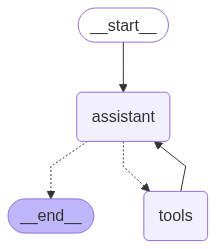

In [38]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [39]:
question = "A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?"
messages = [HumanMessage(content=question)]
messages = graph.invoke({"messages": messages})

In [40]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

A paper about AI regulation that was originally submitted to arXiv.org in June 2022 shows a figure with three axes, where each axis has a label word at both ends. Which of these words is used to describe a type of society in a Physics and Society article submitted to arXiv.org on August 11, 2016?
================================== Ai Message ==================================
Tool Calls:
  arvix_search (cf1968e8-053c-4d75-a59f-eb196dfed2a4)
 Call ID: cf1968e8-053c-4d75-a59f-eb196dfed2a4
  Args:
    query: AI regulation June 2022 figure three axes
================================= Tool Message =================================
Name: arvix_search

{"arvix_results": "<Document title=\"Fairness in Agreement With European Values: An Interdisciplinary Perspective on AI Regulation\" published=\"2022-06-08\"/>\nFairness in Agreement With European Values: An\nInterdisciplinary Perspective on AI Regulation\nAlejand

In [41]:
question = "In April of 1977, who was the Prime Minister of the first place mentioned by name in the Book of Esther (in the New International Version)?"
messages = [HumanMessage(content=question)]
messages = graph.invoke({"messages": messages})

In [42]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

In April of 1977, who was the Prime Minister of the first place mentioned by name in the Book of Esther (in the New International Version)?
================================== Ai Message ==================================
Tool Calls:
  web_search (6bf1f2de-2483-4772-8b41-f08cb78832ae)
 Call ID: 6bf1f2de-2483-4772-8b41-f08cb78832ae
  Args:
    query: first place mentioned by name in the Book of Esther New International Version
================================= Tool Message =================================
Name: web_search

{"web_results": "<Document source=\"https://biblehub.com/esther/1-1.htm\" title=\"Esther 1:1 This is what happened in the days of Xerxes, who reigned ...\"/>\nsouthern reaches of Egypt and Sudan. The mention of these regions highlights the diversity and the strategic importance of the empire's territories. It also sets the stage for understanding the multicultural context in which Esther

In [43]:
# check last message
messages['messages'][-1].content

'FINAL ANSWER: Morarji Desai'